In [1]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from analysis import Analysis

PyHEADTAIL v1.16.5


# Ensemble of particles with no sc

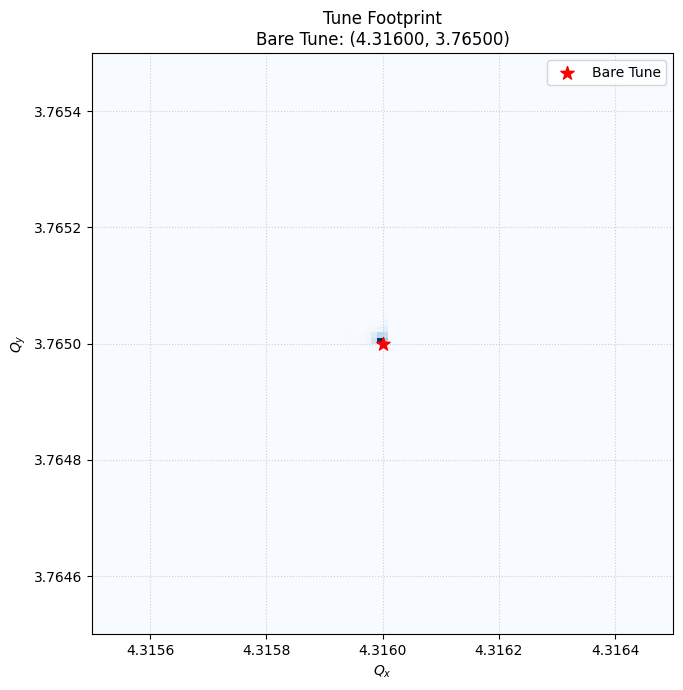

In [3]:
analysis = Analysis('no_sc')
analysis.tune_histogram(x_lims=(4.3155,4.3165), y_lims=(3.7645,3.7655))

# Ensemble of particle with varying sc

#####################################
10000000000.0
mine


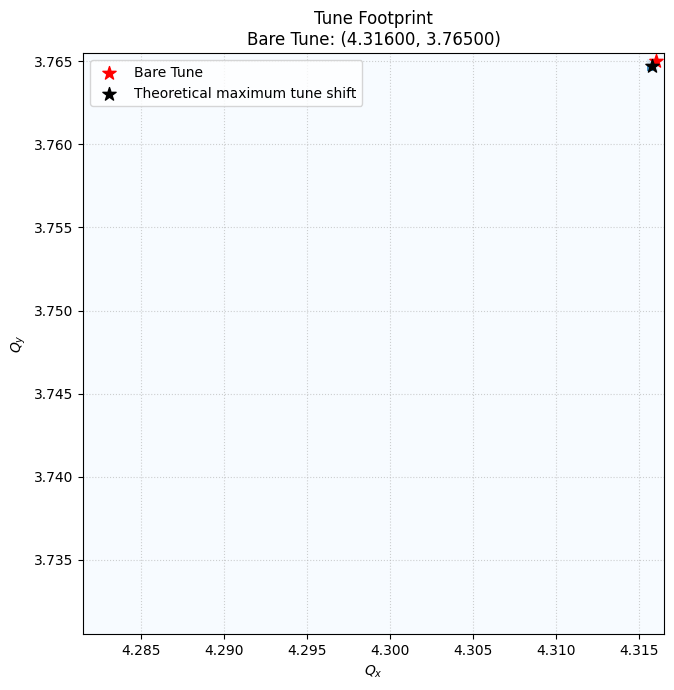

xfield


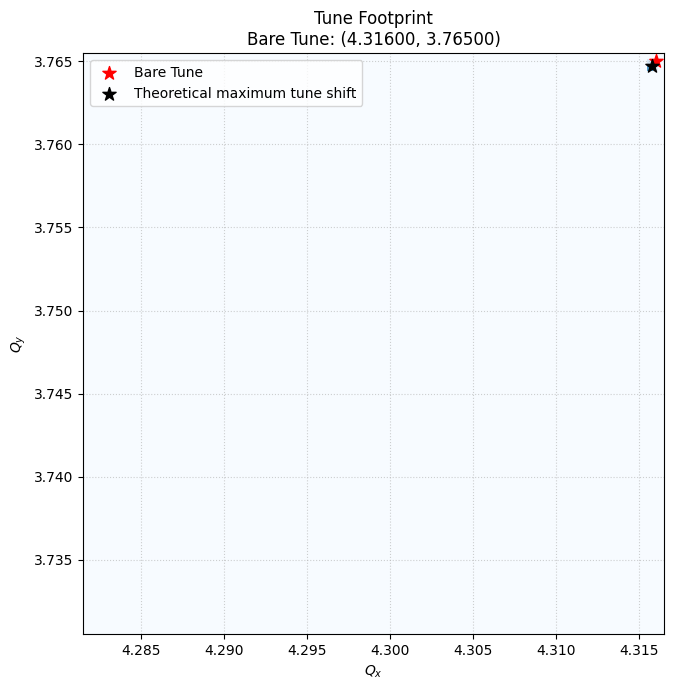

#####################################
40000000000.0
mine


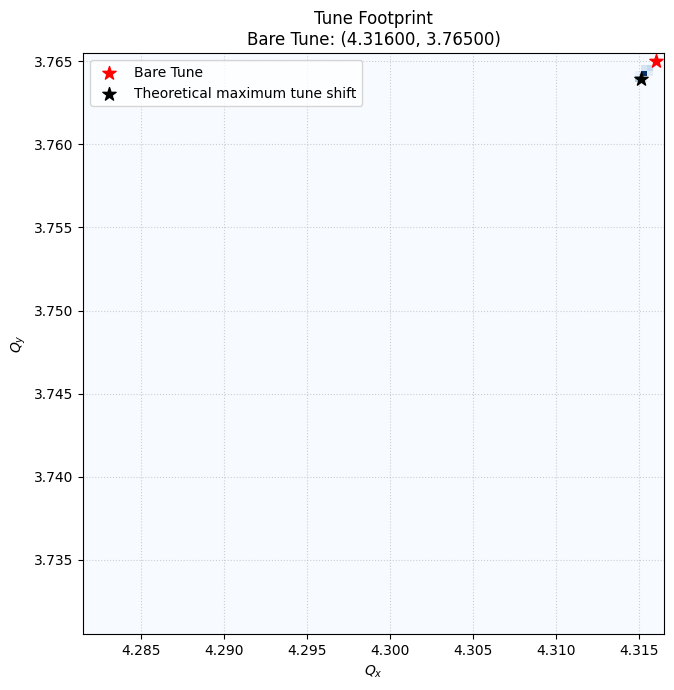

xfield


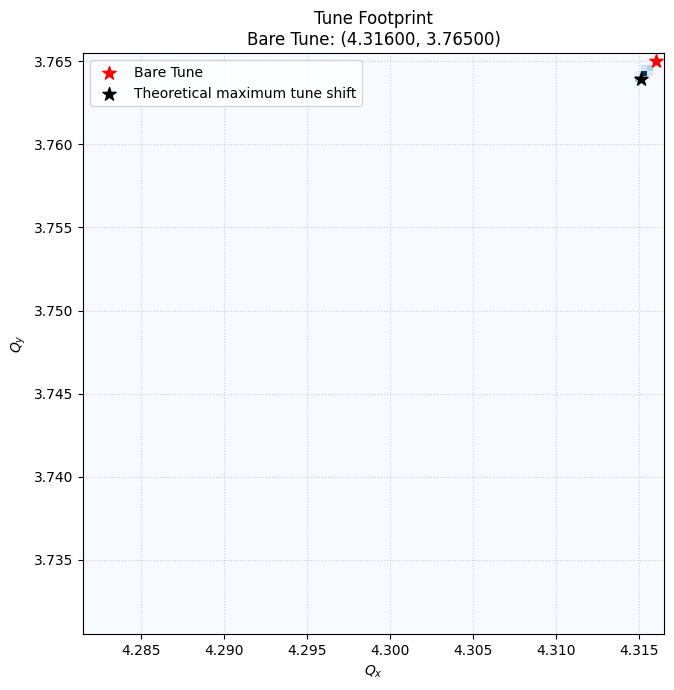

#####################################
100000000000.0
mine


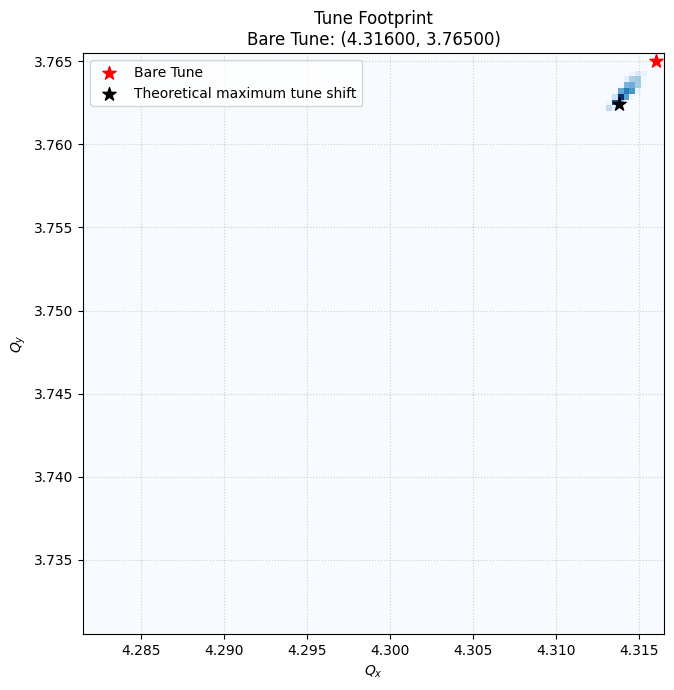

xfield


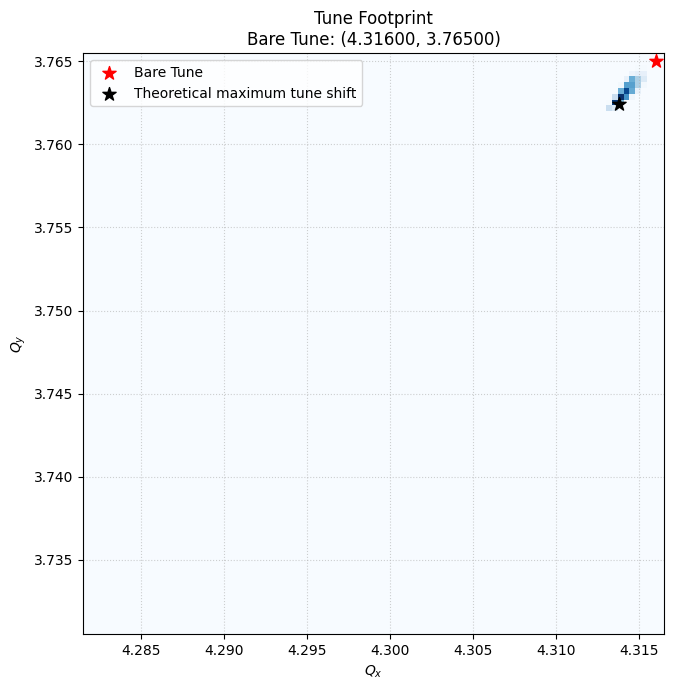

#####################################
400000000000.0
mine


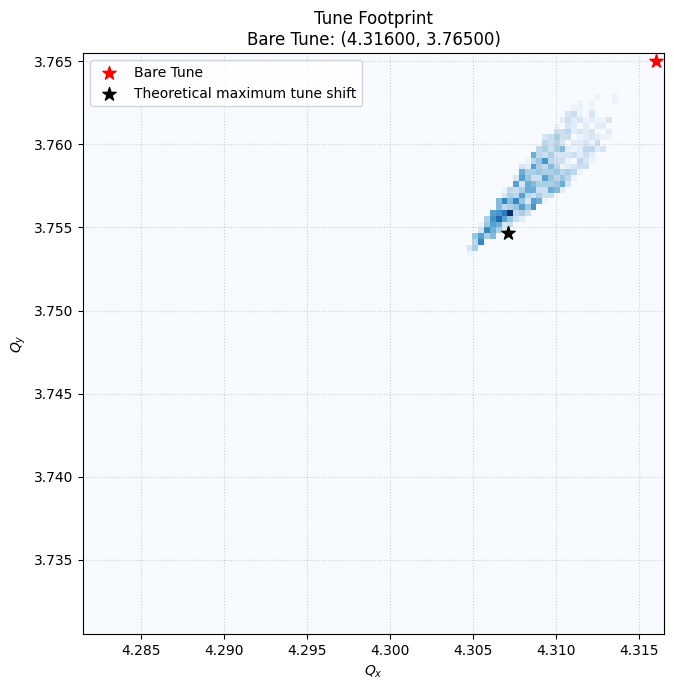

xfield


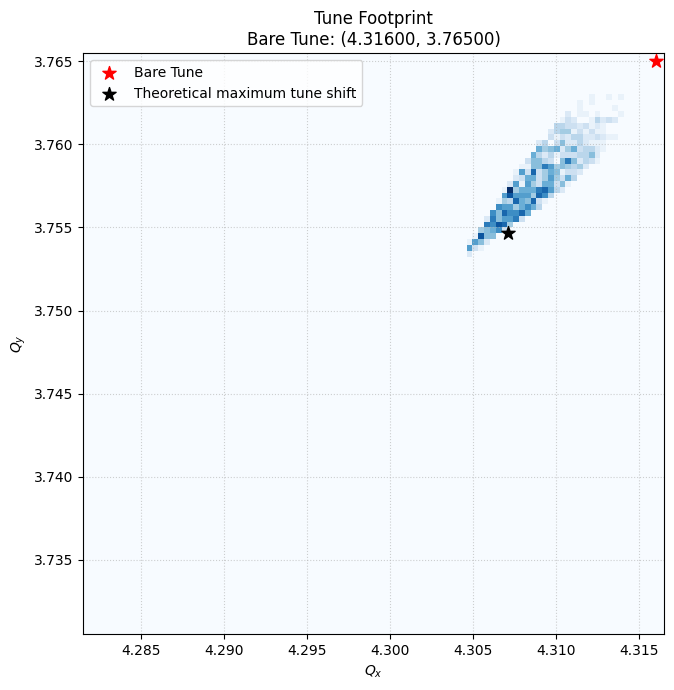

#####################################
1000000000000.0
mine


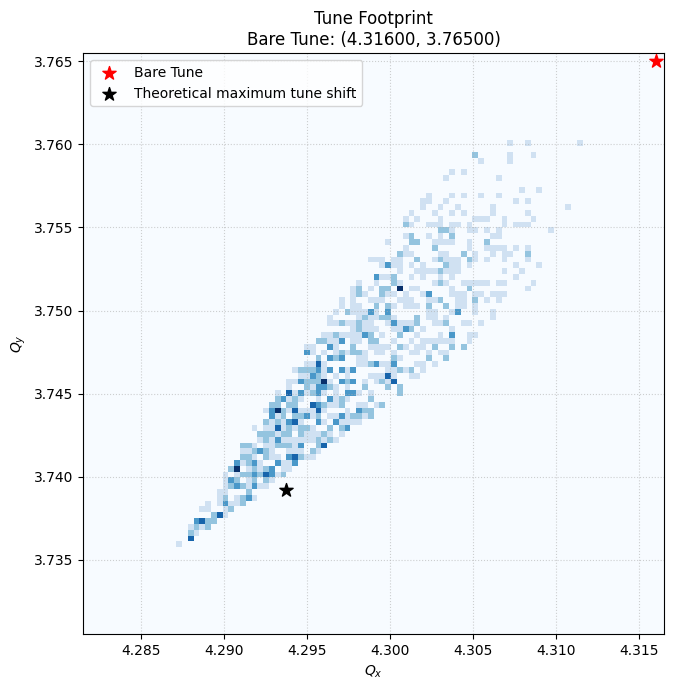

xfield


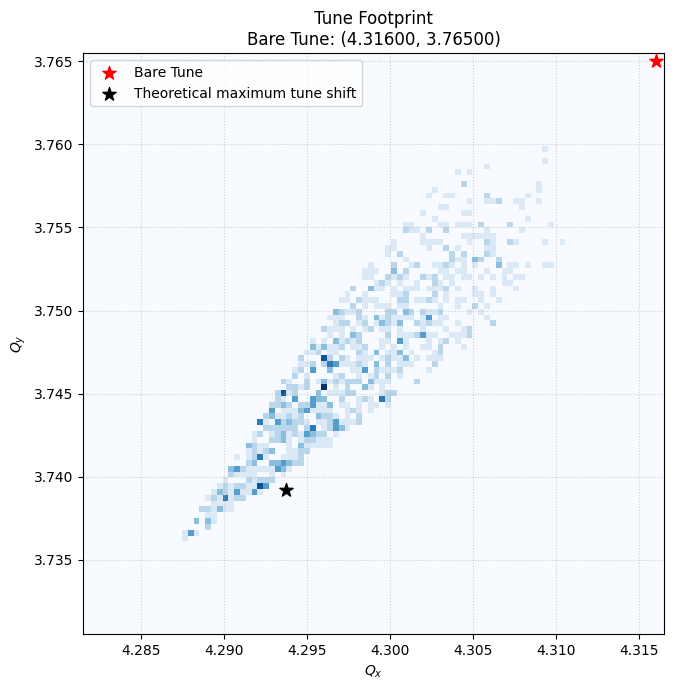

In [6]:
beam_intensity_list = [1e10, 4e10, 1e11, 4e11, 1e12]

max_detune_x_list = []
max_detune_y_list = []
max_detune_x_xf_list = []
max_detune_y_xf_list = []

mean_detune_x_list = []
mean_detune_y_list = []
mean_detune_x_xf_list = []
mean_detune_y_xf_list = []

theory_detune_x_list = []
theory_detune_y_list = []

for beam_intensity in beam_intensity_list:
    print('#####################################')
    print(beam_intensity)
    print('mine')
    analysis = Analysis(f'sweep_beam_intensity/{beam_intensity}')
    analysis.tune_histogram(x_lims=(4.2815,4.3165), 
                            y_lims=(3.7305,3.7655)
                           )
    max_detune_x_list.append(np.max(analysis.qx-analysis.Qx))
    max_detune_y_list.append(np.max(analysis.qy-analysis.Qy))
    mean_detune_x_list.append(np.mean(analysis.qx-analysis.Qx))
    mean_detune_y_list.append(np.mean(analysis.qy-analysis.Qy))
    
    theory_detune_x_list.append(analysis.DQx)
    theory_detune_y_list.append(analysis.DQy)

    
    print('xfield')
    analysis = Analysis(f'sweep_beam_intensity/xf_{beam_intensity}')
    analysis.tune_histogram(x_lims=(4.2815,4.3165), 
                            y_lims=(3.7305,3.7655))
   
    max_detune_x_xf_list.append(np.max(analysis.qx-analysis.Qx))
    max_detune_y_xf_list.append(np.max(analysis.qy-analysis.Qy))
    mean_detune_x_xf_list.append(np.mean(analysis.qx-analysis.Qx))
    mean_detune_y_xf_list.append(np.mean(analysis.qy-analysis.Qy))

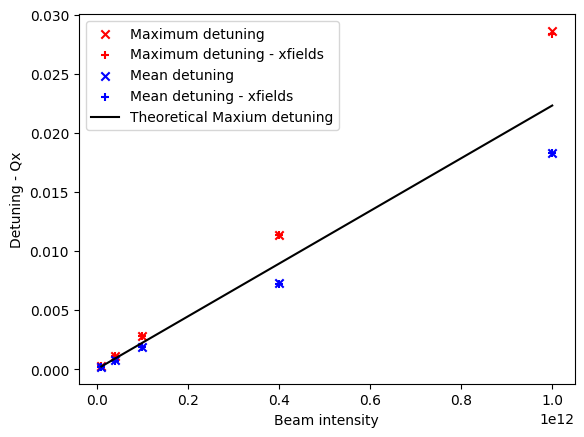

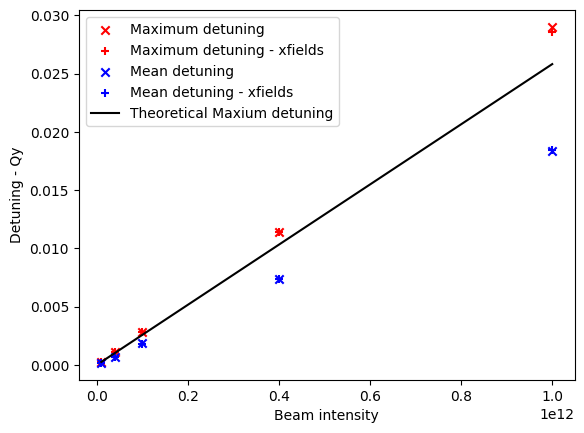

In [14]:
plt.scatter(beam_intensity_list, max_detune_x_list, marker='x', c='r', label='Maximum detuning')
plt.scatter(beam_intensity_list, max_detune_x_xf_list, marker='+', c='r', label='Maximum detuning - xfields')
plt.scatter(beam_intensity_list, mean_detune_x_list, marker='x', c='b', label='Mean detuning')
plt.scatter(beam_intensity_list, mean_detune_x_xf_list, marker='+', c='b', label='Mean detuning - xfields')
plt.plot(beam_intensity_list, theory_detune_x_list, c='k', label='Theoretical Maxium detuning')
plt.xlabel('Beam intensity')
plt.ylabel('Detuning - Qx')
plt.legend()
plt.show()

plt.scatter(beam_intensity_list, max_detune_y_list, marker='x', c='r', label='Maximum detuning')
plt.scatter(beam_intensity_list, max_detune_y_xf_list, marker='+', c='r', label='Maximum detuning - xfields')
plt.scatter(beam_intensity_list, mean_detune_y_list, marker='x', c='b', label='Mean detuning')
plt.scatter(beam_intensity_list, mean_detune_y_xf_list, marker='+', c='b', label='Mean detuning - xfields')
plt.plot(beam_intensity_list, theory_detune_y_list, c='k', label='Theoretical Maxium detuning')
plt.xlabel('Beam intensity')
plt.ylabel('Detuning - Qy')
plt.legend()
plt.show()

In [19]:
import pandas as pd
analysis.df_twiss.to_csv('twiss.csv')